# Results and Analysis Notebook

## Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE_ROOT = "/content/drive/MyDrive/ds266_idiom_mt"
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
RESULTS_DIR = os.path.join(DRIVE_ROOT, "results")
CACHE_DIR = os.path.join(DRIVE_ROOT, "cache")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# Make HF cache persistent
os.environ["HF_HOME"] = CACHE_DIR
os.environ["TRANSFORMERS_CACHE"] = CACHE_DIR
os.environ["HF_DATASETS_CACHE"] = CACHE_DIR

print("DRIVE_ROOT:", DRIVE_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CACHE_DIR:", CACHE_DIR)

Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/ds266_idiom_mt
CHECKPOINT_DIR: /content/drive/MyDrive/ds266_idiom_mt/checkpoints
RESULTS_DIR: /content/drive/MyDrive/ds266_idiom_mt/results
CACHE_DIR: /content/drive/MyDrive/ds266_idiom_mt/cache


## Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

## Analysis

Analysis of all experiments which were ran with the Helsinki-NLP model family

In [ ]:
METRICS_PATH = os.path.join(RESULTS_DIR, "metrics_with_model_family.csv")

In [ ]:
df = pd.read_csv(METRICS_PATH)

# Filter for model_family == "Helsinki-NLP"
df = df[df["model_family"] == "Helsinki-NLP"]

In [ ]:
# Overview of all runs
df["timestamp"] = pd.to_datetime(df["timestamp"])
df_latest = df.sort_values("timestamp").drop_duplicates(["run_name","split"], keep="last")
pivot = df_latest.pivot(index="run_name", columns="split", values=["bleu","chrf"])
pivot

bleu                   chrf  \
split                                   idioms_test   wmt_test idioms_test   
run_name                                                                     
baseline                                  39.649352  27.567994   60.786112   
idiom_only_v1                             44.002204  26.835303   64.149875   
lora_r16_two_stage_beam4_lp0.8            40.437899  27.724105   60.811025   
lora_r16_two_stage_beam4_lp1.0            40.685791  27.664992   60.942063   
lora_r16_two_stage_beam4_lp1.2            41.091597  27.582485   61.209497   
lora_r16_two_stage_beam8_lp0.8            40.781721  27.747897   60.814746   
lora_r16_two_stage_beam8_lp1.0            41.066878  27.666457   61.230413   
lora_r16_two_stage_beam8_lp1.2            41.540317  27.538303   61.613786   
lora_r16_two_stage_greedy                 41.724245  27.596422   61.449820   
lora_r4_two_stage_beam4_lp0.8             40.768980  27.614264   60.621006   
lora_r4_two_stage_beam4_lp1.0             41.168476  27.539686   61.094723   
lora_r4_two_stage_beam4_lp1.2             41.699884  27.495112   61.387122   
lora_r4_two_stage_beam8_lp0.8             40.659326  27.787373   60.680309   
lora_r4_two_stage_beam8_lp1.0             40.942177  27.732565   61.187899   
lora_r4_two_stage_beam8_lp1.2             41.374154  27.655243   61.560170   
lora_r4_two_stage_greedy                  41.809158  27.467714   61.681717   
lora_r8_two_stage_beam4_lp0.8             40.822551  27.600403   60.796521   
lora_r8_two_stage_beam4_lp1.0             41.354007  27.516678   61.232903   
lora_r8_two_stage_beam4_lp1.2             41.401500  27.475783   61.324065   
lora_r8_two_stage_beam8_lp0.8             40.891224  27.717495   60.852900   
lora_r8_two_stage_beam8_lp1.0             41.306800  27.633059   61.352944   
lora_r8_two_stage_beam8_lp1.2             41.600988  27.506993   61.607447   
lora_r8_two_stage_greedy                  42.178766  27.480339   61.760909   
lora_two_stage_v1_beam4                   41.312336  27.582875   61.137901   
lora_two_stage_v1_beam8                   41.535869  27.708663   61.414298   
lora_two_stage_v1_greedy                  41.637818  27.550069   61.470424   
two_stage_frozen_v1                       43.609125  27.096051   63.502816   
two_stage_mixed_wd_es_v1                  28.724105  22.412510   50.737157   
two_stage_mixed_wd_es_v2                  31.678599  21.100049   53.415673   
two_stage_wmt_only_freeze_dec1_lr1e5_v1   30.081818  22.304616   51.762017   

                                                    
split                                     wmt_test  
run_name                                            
baseline                                 58.431846  
idiom_only_v1                            58.301715  
lora_r16_two_stage_beam4_lp0.8           58.423499  
lora_r16_two_stage_beam4_lp1.0           58.457663  
lora_r16_two_stage_beam4_lp1.2           58.467085  
lora_r16_two_stage_beam8_lp0.8           58.427614  
lora_r16_two_stage_beam8_lp1.0           58.469909  
lora_r16_two_stage_beam8_lp1.2           58.479583  
lora_r16_two_stage_greedy                58.459373  
lora_r4_two_stage_beam4_lp0.8            58.415911  
lora_r4_two_stage_beam4_lp1.0            58.417119  
lora_r4_two_stage_beam4_lp1.2            58.475618  
lora_r4_two_stage_beam8_lp0.8            58.450781  
lora_r4_two_stage_beam8_lp1.0            58.495137  
lora_r4_two_stage_beam8_lp1.2            58.565315  
lora_r4_two_stage_greedy                 58.434768  
lora_r8_two_stage_beam4_lp0.8            58.436460  
lora_r8_two_stage_beam4_lp1.0            58.440033  
lora_r8_two_stage_beam4_lp1.2            58.458803  
lora_r8_two_stage_beam8_lp0.8            58.421674  
lora_r8_two_stage_beam8_lp1.0            58.467520  
lora_r8_two_stage_beam8_lp1.2            58.480484  
lora_r8_two_stage_greedy                 58.459796  
lora_two_stage_v1_beam4                  58.426129  
lora_two_stage_v1_beam8                  

## Performance Improvement Analysis (vs Baseline)
not yet sorted

In [ ]:
# Trade-off summary
trade = pd.DataFrame({
    "idioms_bleu_change": summary["idioms_test_bleu"] - summary.loc["baseline","idioms_test_bleu"],
    "wmt_bleu_change":  summary["wmt_test_bleu"] - summary.loc["baseline","wmt_test_bleu"],
    "idioms_chrf_change": summary["idioms_test_chrf"] - summary.loc["baseline","idioms_test_chrf"],
    "wmt_chrf_change":  summary["wmt_test_chrf"] - summary.loc["baseline","wmt_test_chrf"],
})
display(trade)

,idioms_bleu_change,wmt_bleu_change,idioms_chrf_change,wmt_chrf_change
run,,,,
baseline,0.000000,0.000000,0.000000,0.000000
idiom_only_v1,4.352852,-0.732691,3.363763,-0.130130
two_stage_frozen_v1,3.959773,-0.471943,2.716704,-0.129112
two_stage_mixed_wd_es_v1,-10.925247,-5.155484,-10.048955,-4.552958
two_stage_mixed_wd_es_v2,-7.970753,-6.467945,-7.370439,-6.940596
two_stage_wmt_only_freeze_dec1_lr1e5_v1,-9.567534,-5.263379,-9.024095,-4.886907
lora_two_stage_v1_greedy,1.988466,-0.017925,0.684312,0.009757
lora_two_stage_v1_beam4,1.662984,0.014881,0.351789,-0.005717
lora_two_stage_v1_beam8,1.886517,0.140669,0.628186,0.066515


## Model Results incl Notes

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Keep latest timestamp
df_latest = (
    df.sort_values("timestamp")
      .drop_duplicates(["run_name", "split"], keep="last")
      .copy()
)

# Keep model_notes for more info
notes_map = (
    df_latest[["run_name", "notes"]]
      .dropna(subset=["notes"])
      .drop_duplicates("run_name", keep="last")
      .set_index("run_name")["notes"]
)

# Summary table
summary = (
    df_latest.pivot(index="run_name", columns="split", values=["bleu", "chrf"])
)

summary.columns = [f"{split}_{metric}" for metric, split in summary.columns]
summary = summary.reset_index().rename(columns={"run_name": "run"}).set_index("run")

# Notes
summary["notes"] = summary.index.map(notes_map)

# Baseline
baseline_run = "baseline"
baseline = summary.loc[baseline_run]

summary

,idioms_test_bleu,wmt_test_bleu,idioms_test_chrf,wmt_test_chrf,notes
run,,,,,
baseline,39.649352,27.567994,60.786112,58.431846,pretrained baseline (WMT test full 3003)
idiom_only_v1,44.002204,26.835303,64.149875,58.301715,stage1 idiom-only fine-tune (eval on WMT)
lora_r16_two_stage_beam4_lp0.8,40.437899,27.724105,60.811025,58.423499,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam4_lp1.0,40.685791,27.664992,60.942063,58.457663,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam4_lp1.2,41.091597,27.582485,61.209497,58.467085,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam8_lp0.8,40.781721,27.747897,60.814746,58.427614,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam8_lp1.0,41.066878,27.666457,61.230413,58.469909,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam8_lp1.2,41.540317,27.538303,61.613786,58.479583,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_greedy,41.724245,27.596422,61.449820,58.459373,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...


## Performance Improvement Analysis (vs Baseline) with Notes

In [ ]:
# Table with Delta vs Baseline Performance Scores
trade = pd.DataFrame({
    "wmt_bleu_change": summary["wmt_test_bleu"] - baseline["wmt_test_bleu"],
    "idioms_bleu_change": summary["idioms_test_bleu"] - baseline["idioms_test_bleu"],
    "wmt_chrf_change": summary["wmt_test_chrf"] - baseline["wmt_test_chrf"],
    "idioms_chrf_change": summary["idioms_test_chrf"] - baseline["idioms_test_chrf"],
    "notes": summary["notes"],
})

### Best WMT

First sorted by *wmt_bleu_change*, then by *idioms_bleu_change*, from best to worst

In [ ]:
# Find best WMT score
trade_sorted = trade.sort_values(
    by=["wmt_bleu_change", "idioms_bleu_change"],
    ascending=[False, False]
)

display(trade_sorted)

,wmt_bleu_change,idioms_bleu_change,wmt_chrf_change,idioms_chrf_change,notes
run,,,,,
lora_r4_two_stage_beam8_lp0.8,0.219379,1.009974,0.018935,-0.105803,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_beam8_lp0.8,0.179903,1.132369,-0.004232,0.028634,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r4_two_stage_beam8_lp1.0,0.164571,1.292825,0.063291,0.401787,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_beam4_lp0.8,0.156111,0.788547,-0.008347,0.024913,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r8_two_stage_beam8_lp0.8,0.149501,1.241872,-0.010171,0.066788,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...
lora_two_stage_v1_beam8,0.140669,1.886517,0.066515,0.628186,LoRA 2-stage | stage2=WMT enc frozen | decodin...
lora_r16_two_stage_beam8_lp1.0,0.098463,1.417526,0.038063,0.444301,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam4_lp1.0,0.096998,1.036439,0.025817,0.155951,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r4_two_stage_beam8_lp1.2,0.087249,1.724802,0.133470,0.774058,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...


### Best IDIOM

First sorted by idioms_bleu_change*, then by *wmt_bleu_change**, from best to worst

In [ ]:
# Find best IDIOM score
trade_sorted = trade.sort_values(
    by=["idioms_bleu_change", "wmt_bleu_change"],
    ascending=[False, False]
)

display(trade_sorted)

,wmt_bleu_change,idioms_bleu_change,wmt_chrf_change,idioms_chrf_change,notes
run,,,,,
idiom_only_v1,-0.732691,4.352852,-0.130130,3.363763,stage1 idiom-only fine-tune (eval on WMT)
two_stage_frozen_v1,-0.471943,3.959773,-0.129112,2.716704,"stage2 general fine-tune, encoder frozen (eval..."
lora_r8_two_stage_greedy,-0.087655,2.529414,0.027950,0.974797,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...
lora_r4_two_stage_greedy,-0.100280,2.159806,0.002922,0.895605,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_greedy,0.028428,2.074893,0.027528,0.663708,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r4_two_stage_beam4_lp1.2,-0.072882,2.050533,0.043772,0.601010,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_two_stage_v1_greedy,-0.017925,1.988466,0.009757,0.684312,LoRA 2-stage | stage2=WMT enc frozen | decodin...
lora_r8_two_stage_beam8_lp1.2,-0.061002,1.951636,0.048639,0.821335,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_beam8_lp1.2,-0.029691,1.890965,0.047737,0.827674,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...


### Best WMT-preserving models (both Idiom and WMT >0)

In [ ]:
# Find best WMT-preserving score with both idiom and wmt socres >0
trade_sorted = trade.sort_values(
    by=["idioms_bleu_change", "wmt_bleu_change"],
    ascending=[False, False]
)

trade_sorted_geq0 = trade_sorted[(trade_sorted['idioms_bleu_change'] >= 0) & (trade_sorted['wmt_bleu_change'] >= 0)]

display(trade_sorted_geq0)

,wmt_bleu_change,idioms_bleu_change,wmt_chrf_change,idioms_chrf_change,notes
run,,,,,
lora_r16_two_stage_greedy,0.028428,2.074893,0.027528,0.663708,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_two_stage_v1_beam8,0.140669,1.886517,0.066515,0.628186,LoRA 2-stage | stage2=WMT enc frozen | decodin...
lora_r4_two_stage_beam8_lp1.2,0.087249,1.724802,0.133470,0.774058,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_two_stage_v1_beam4,0.014881,1.662984,-0.005717,0.351789,LoRA 2-stage | stage2=WMT enc frozen | decodin...
lora_r8_two_stage_beam8_lp1.0,0.065065,1.657448,0.035674,0.566832,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_beam4_lp1.2,0.014491,1.442245,0.035239,0.423385,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r16_two_stage_beam8_lp1.0,0.098463,1.417526,0.038063,0.444301,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
lora_r4_two_stage_beam8_lp1.0,0.164571,1.292825,0.063291,0.401787,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_r8_two_stage_beam8_lp0.8,0.149501,1.241872,-0.010171,0.066788,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...


### Most interesting Models

1. Baseline (baseline)
2. Catastrophic Idiom Specialist (idiom_only_v1)
3. Best Idiom LoRA (lora_r8_two_stage_greedy)
4. Best WMT-Preserving LoRA (lora_r4_two_stage_beam8_lp0.8)
5. Balanced Pareto Candidate (lora_r16_two_stage_greedy)

In [ ]:
run_names_top_5 = ["baseline",
     "idiom_only_v1",
     "lora_r8_two_stage_greedy",
     "lora_r4_two_stage_beam8_lp0.8",
     "lora_r16_two_stage_greedy"
]

In [ ]:
# Filter for the 5 most interesting model scores
trade_top_5 = trade[trade.index.isin(run_names_top_5)]

trade_sorted_top_5 = trade_top_5.sort_values(
    by=["wmt_bleu_change", "idioms_bleu_change"],
    ascending=[False, False]
)

display(trade_sorted_top_5)

,wmt_bleu_change,idioms_bleu_change,wmt_chrf_change,idioms_chrf_change,notes
run,,,,,
lora_r4_two_stage_beam8_lp0.8,0.219379,1.009974,0.018935,-0.105803,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...
lora_r16_two_stage_greedy,0.028428,2.074893,0.027528,0.663708,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...
baseline,0.000000,0.000000,0.000000,0.000000,pretrained baseline (WMT test full 3003)
lora_r8_two_stage_greedy,-0.087655,2.529414,0.027950,0.974797,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...
idiom_only_v1,-0.732691,4.352852,-0.130130,3.363763,stage1 idiom-only fine-tune (eval on WMT)


## Plots

/tmp/ipykernel_1559/4111215992.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trade_sorted.index, rotation=90, ha='right')


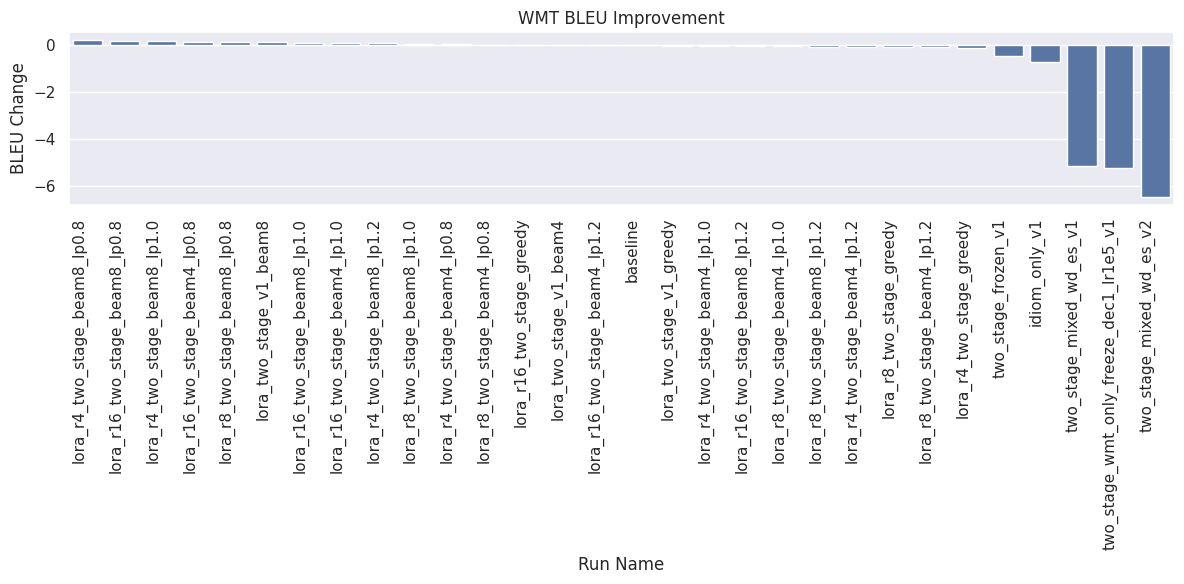

In [ ]:
# WMT BLEU change of all models
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=trade_sorted.index, y=trade_sorted["wmt_bleu_change"], ax=ax)
ax.set_xticklabels(trade_sorted.index, rotation=90, ha='right')
plt.title("WMT BLEU Improvement")
plt.ylabel("BLEU Change")
plt.xlabel("Run Name")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1559/2673655556.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trade_sorted_top_5.index, rotation=90, ha='right')


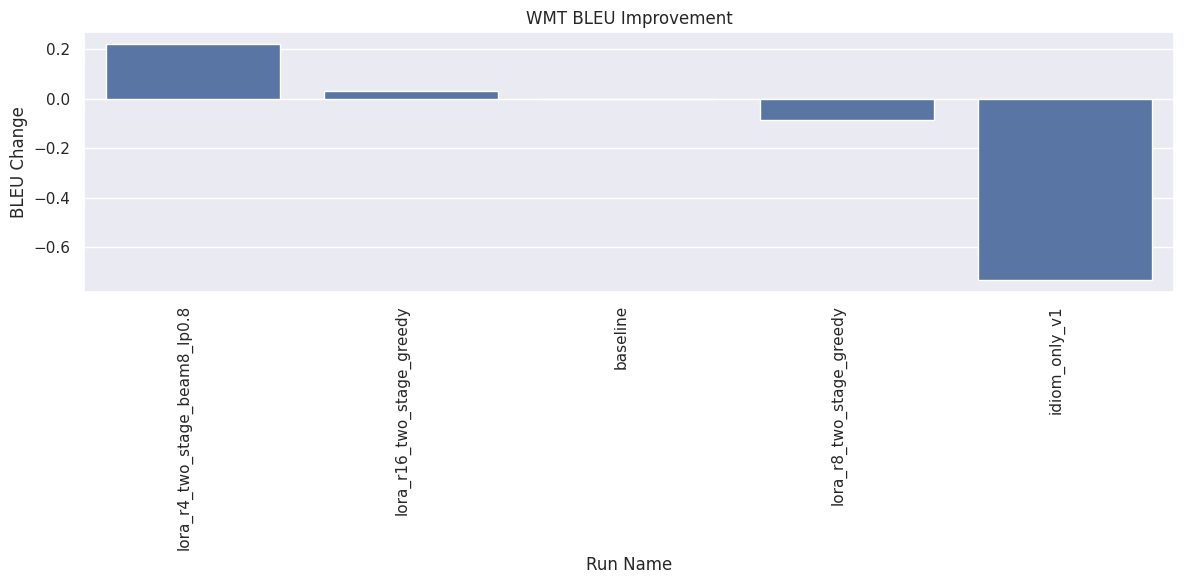

In [ ]:
# WMT BLEU change of 5 most interesting models
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=trade_sorted_top_5.index, y=trade_sorted_top_5["wmt_bleu_change"], ax=ax)
ax.set_xticklabels(trade_sorted_top_5.index, rotation=90, ha='right')
plt.title("WMT BLEU Improvement")
plt.ylabel("BLEU Change")
plt.xlabel("Run Name")
plt.tight_layout()
plt.show()

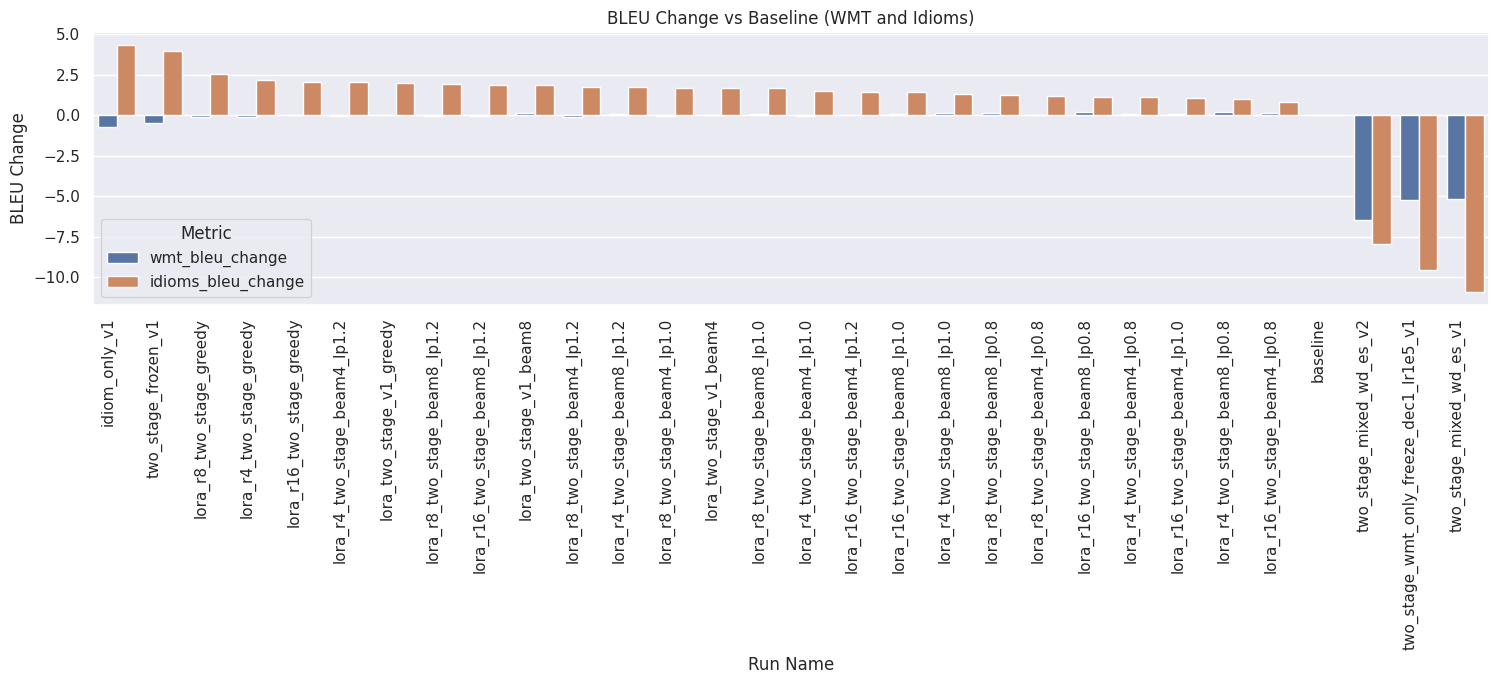

In [ ]:
# WMT + IDIOMS BLEU change of all models
trade_melted = trade_sorted.reset_index().melt(id_vars=['run', 'notes'], value_vars=['wmt_bleu_change', 'idioms_bleu_change'], var_name='metric', value_name='bleu_change')

plt.figure(figsize=(15, 7))
sns.barplot(x='run', y='bleu_change', hue='metric', data=trade_melted)
plt.title('BLEU Change vs Baseline (WMT and Idioms)')
plt.xlabel('Run Name')
plt.ylabel('BLEU Change')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

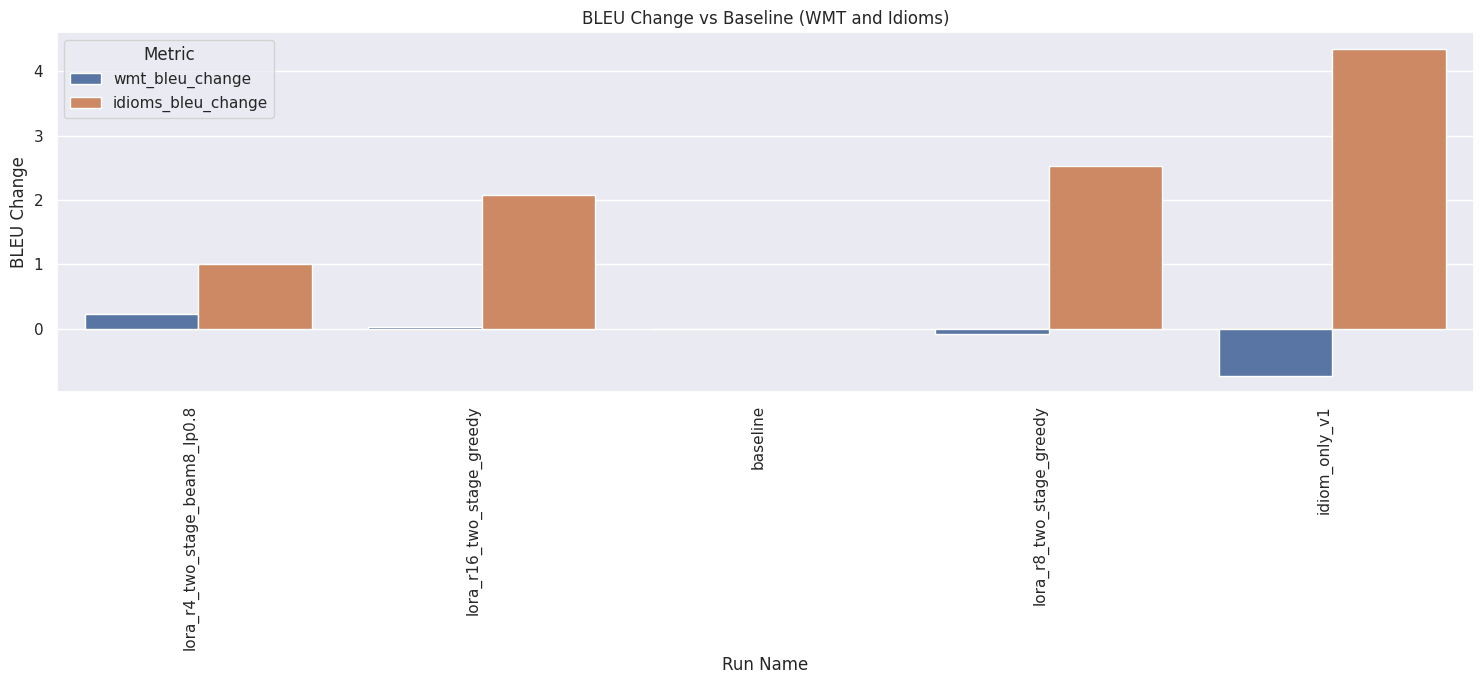

In [ ]:
# WMT + IDIOMS BLEU change of 5 most interesting models

trade_melted = trade_sorted_top_5.reset_index().melt(id_vars=['run', 'notes'], value_vars=['wmt_bleu_change', 'idioms_bleu_change'], var_name='metric', value_name='bleu_change')

plt.figure(figsize=(15, 7))
sns.barplot(x='run', y='bleu_change', hue='metric', data=trade_melted)
plt.title('BLEU Change vs Baseline (WMT and Idioms)')
plt.xlabel('Run Name')
plt.ylabel('BLEU Change')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()